In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [5]:
nav = pd.read_csv("../data/processed/clean_nav.csv")
txn = pd.read_csv("../data/processed/clean_transactions.csv")
portfolio = pd.read_csv("../data/processed/clean_portfolio_holdings.csv")
fund = pd.read_csv("../data/processed/clean_fund_master.csv")
sharpe_df = pd.read_csv("../data/processed/sharpe_values.csv")

In [6]:
nav['date'] = pd.to_datetime(nav['date'])

In [7]:
txn['transaction_date'] = pd.to_datetime(txn['transaction_date'])

In [8]:
nav = nav.sort_values(['amfi_code', 'date'])
nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()
nav_returns = nav.dropna(subset=['daily_return']).copy()

In [9]:
var_cvar_list = []

for code, group in nav_returns.groupby('amfi_code'):
    returns = group['daily_return']
    
    # Historical VaR at 95%
    var_95 = np.percentile(returns, 5)
    
    # CVaR = mean of returns below VaR
    cvar_95 = returns[returns <= var_95].mean()
    
    var_cvar_list.append({
        'amfi_code': code,
        'var_95': round(var_95 * 100, 4),
        'cvar_95': round(cvar_95 * 100, 4)
    })

var_cvar_df = pd.DataFrame(var_cvar_list)
var_cvar_df = var_cvar_df.merge(
    fund[['amfi_code', 'scheme_name', 'fund_house']], 
    on='amfi_code', how='left')

print(var_cvar_df.sort_values('var_95').head(10))

    amfi_code  var_95  cvar_95  \
22     119599 -2.6859  -3.2384   
17     119095 -2.6188  -3.1667   
4      101207 -2.6021  -3.2459   
11     118634 -2.5438  -3.2304   
21     119598 -2.4507  -3.0595   
39     149324 -2.3483  -3.1036   
7      102886 -1.9220  -2.3251   
2      100033 -1.9034  -2.3456   
25     120505 -1.8892  -2.4342   
16     119094 -1.8480  -2.4260   

                                          scheme_name  \
22          SBI Small Cap Fund - Direct Plan - Growth   
17             Axis Small Cap Fund - Regular - Growth   
4              ABSL Small Cap Fund - Regular - Growth   
11     Nippon India Small Cap Fund - Regular - Growth   
21         SBI Small Cap Fund - Regular Plan - Growth   
39              DSP Small Cap Fund - Regular - Growth   
7                 UTI Mid Cap Fund - Regular - Growth   
2   HDFC Mid-Cap Opportunities Fund - Regular - Gr...   
25           ICICI Pru Midcap Fund - Regular - Growth   
16                Axis Midcap Fund - Regular - Growth  

In [10]:
var_cvar_df.to_csv("../data/processed/var_cvar_report.csv", index=False)

In [17]:
Rf = 0.065 / 252

# Pick top 5 funds by AUM
top5 = fund.nlargest(5, 'min_lumpsum_amount')['amfi_code'].tolist()
top5_names = fund[fund['amfi_code'].isin(top5)].set_index('amfi_code')['scheme_name'].to_dict()

rolling_sharpe_list = {}

for code in top5:
    group = nav_returns[nav_returns['amfi_code'] == code].set_index('date')['daily_return']
    rolling_mean = group.rolling(90).mean()
    rolling_std = group.rolling(90).std()
    rolling_sharpe = (rolling_mean - Rf) / rolling_std * np.sqrt(252)
    rolling_sharpe_list[top5_names[code][:25]] = rolling_sharpe

rolling_df = pd.DataFrame(rolling_sharpe_list)
print(rolling_df.tail())

            ICICI Pru Liquid Fund - R  Kotak Liquid Fund - Regul  \
date                                                               
2026-05-25                   1.691075                   0.523244   
2026-05-26                   1.616853                   0.884428   
2026-05-27                   1.696603                   1.200818   
2026-05-28                   1.538528                   1.640807   
2026-05-29                   1.719492                   1.652530   

            ABSL Liquid Fund - Regula  SBI Bluechip Fund - Regul  \
date                                                               
2026-05-25                  -0.055555                   3.148684   
2026-05-26                  -0.025412                   2.932662   
2026-05-27                   0.255620                   2.451461   
2026-05-28                   0.037315                   2.608857   
2026-05-29                   0.707627                   2.516944   

            SBI Bluechip Fund - Direc  
date  

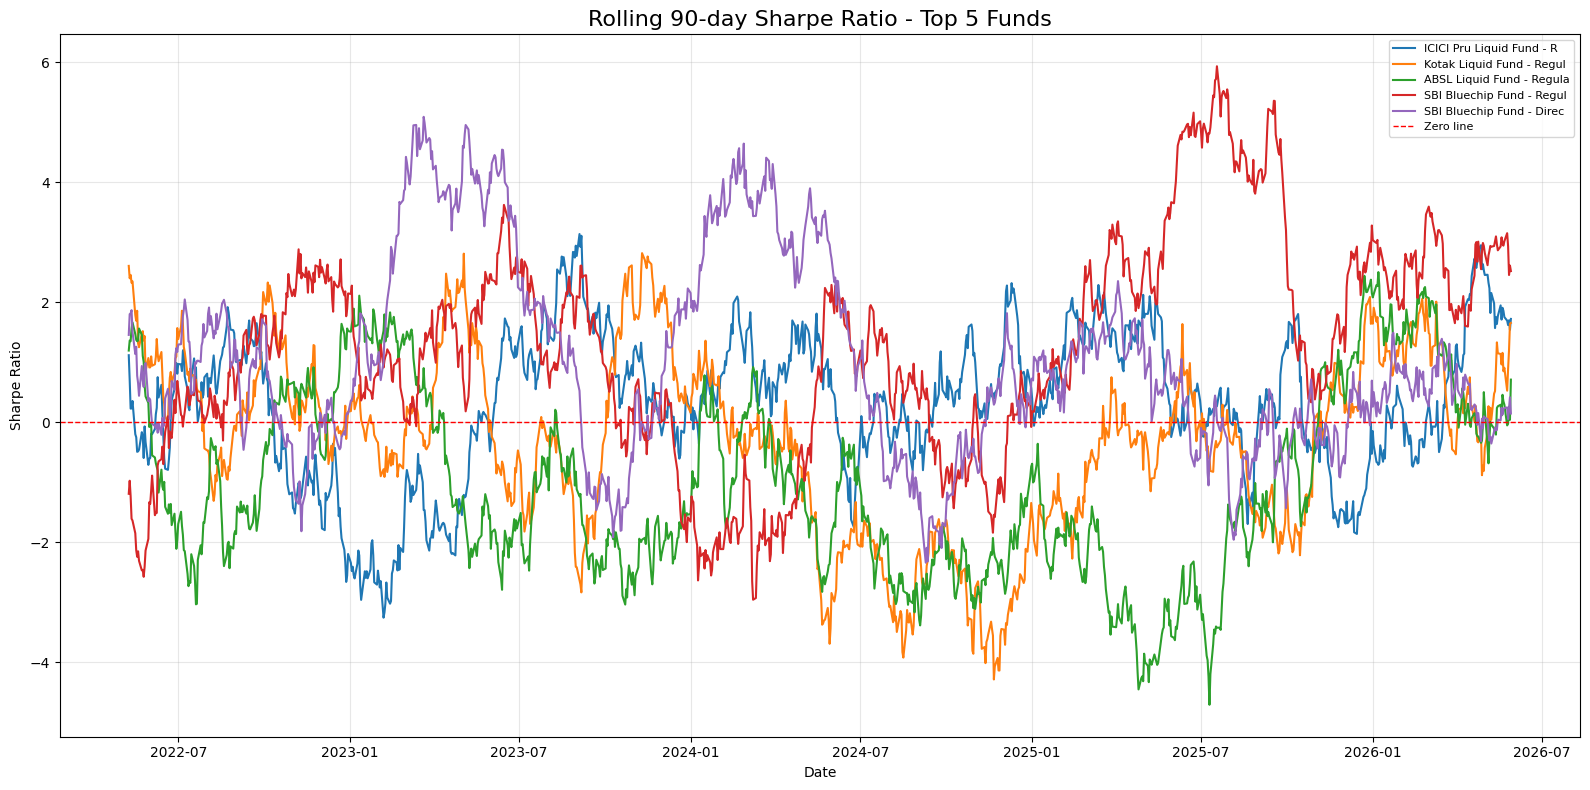

In [18]:
plt.figure(figsize=(16, 8))

for col in rolling_df.columns:
    plt.plot(rolling_df.index, rolling_df[col], linewidth=1.5, label=col)

plt.axhline(y=0, color='red', linestyle='--', linewidth=1, label='Zero line')
plt.title('Rolling 90-day Sharpe Ratio - Top 5 Funds', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Sharpe Ratio')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../reports/charts/rolling_sharpe_chart.png")
plt.show()

In [19]:
# Get first transaction year per investor
first_txn = txn.groupby('investor_id')['transaction_date'].min().reset_index()
first_txn['cohort_year'] = first_txn['transaction_date'].dt.year
first_txn = first_txn[['investor_id', 'cohort_year']]

# Merge back with transactions
txn_cohort = txn.merge(first_txn, on='investor_id', how='left')

print(txn_cohort['cohort_year'].value_counts())

cohort_year
2024    32499
2025      279
Name: count, dtype: int64


In [20]:
cohort = txn_cohort.groupby('cohort_year').agg(
    total_investors=('investor_id', 'nunique'),
    avg_sip_amount=('amount_inr', 'mean'),
    total_invested=('amount_inr', 'sum'),
    total_transactions=('investor_id', 'count')
).reset_index()

cohort['avg_sip_amount'] = cohort['avg_sip_amount'].round(2)
cohort['total_invested'] = cohort['total_invested'].round(2)

print(cohort)

   cohort_year  total_investors  avg_sip_amount  total_invested  \
0         2024             4803       107422.54      3491125187   
1         2025              197       109158.58        30455243   

   total_transactions  
0               32499  
1                 279  


In [21]:
fund_pref = txn_cohort.groupby(
    ['cohort_year', 'amfi_code'])['amount_inr'].sum().reset_index()

fund_pref = fund_pref.sort_values(
    ['cohort_year', 'amount_inr'], ascending=[True, False])

top_fund_per_cohort = fund_pref.groupby('cohort_year').first().reset_index()
top_fund_per_cohort = top_fund_per_cohort.merge(
    fund[['amfi_code', 'scheme_name']], on='amfi_code', how='left')

print(top_fund_per_cohort[['cohort_year', 'scheme_name', 'amount_inr']])

   cohort_year                                 scheme_name  amount_inr
0         2024  UTI Nifty 50 Index Fund - Regular - Growth   100126141
1         2025   SBI Small Cap Fund - Direct Plan - Growth     1478507


In [22]:
cohort.to_csv("../data/processed/cohort_analysis.csv", index=False)

In [23]:
# Filter only SIP transactions
sip_txn = txn[txn['transaction_type'] == 'SIP'].copy()
sip_txn = sip_txn.sort_values(['investor_id', 'transaction_date'])

# Compute gap between transactions per investor
sip_txn['prev_date'] = sip_txn.groupby('investor_id')['transaction_date'].shift(1)
sip_txn['gap_days'] = (sip_txn['transaction_date'] - sip_txn['prev_date']).dt.days

In [24]:
# Count SIP transactions per investor
sip_count = sip_txn.groupby('investor_id')['transaction_date'].count().reset_index()
sip_count.columns = ['investor_id', 'sip_count']

# Filter investors with 6+ transactions
active_investors = sip_count[sip_count['sip_count'] >= 6]['investor_id'].tolist()

sip_active = sip_txn[sip_txn['investor_id'].isin(active_investors)].copy()
print(f"Investors with 6+ SIP transactions: {len(active_investors)}")

Investors with 6+ SIP transactions: 1362


In [25]:
avg_gap = sip_active.groupby('investor_id')['gap_days'].mean().reset_index()
avg_gap.columns = ['investor_id', 'avg_gap_days']
avg_gap['avg_gap_days'] = avg_gap['avg_gap_days'].round(2)
avg_gap['at_risk'] = avg_gap['avg_gap_days'] > 35

print(f"At-risk investors: {avg_gap['at_risk'].sum()}")
print(f"Safe investors: {(~avg_gap['at_risk']).sum()}")
avg_gap.head(10)

At-risk investors: 1332
Safe investors: 30


,investor_id,avg_gap_days,at_risk
0,INV000004,85.40,True
1,INV000008,70.40,True
2,INV000010,64.80,True
3,INV000011,40.17,True
4,INV000012,57.00,True
5,INV000013,55.33,True
6,INV000014,75.33,True
7,INV000023,58.57,True
8,INV000028,93.60,True
9,INV000029,60.67,True


In [26]:
avg_gap.to_csv("../data/processed/sip_continuity.csv", index=False)